In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df = pd.read_csv("cleaned_titanic.csv")



In [6]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())


(775, 12)
   PassengerId  Survived Pclass                                          Name  \
0            1         0    3rd                       Braund, Mr. Owen Harris   
1            3         1    3rd                        Heikkinen, Miss. Laina   
2            4         1    1st  Futrelle, Mrs. Jacques Heath (Lily May Peel)   
3            5         0    3rd                      Allen, Mr. William Henry   
4            6         0    3rd                              Moran, Mr. James   

      Sex  Age  SibSp  Parch            Ticket     Fare    Cabin     Embarked  
0    male   22      1      0         A/5 21171   7.2500  Unknown  Southampton  
1  female   26      0      0  STON/O2. 3101282   7.9250  Unknown  Southampton  
2  female   35      1      0            113803  53.1000     C123  Southampton  
3    male   35      0      0            373450   8.0500  Unknown  Southampton  
4    male   28      0      0            330877   8.4583  Unknown   Queenstown  
<class 'pandas.core.fra

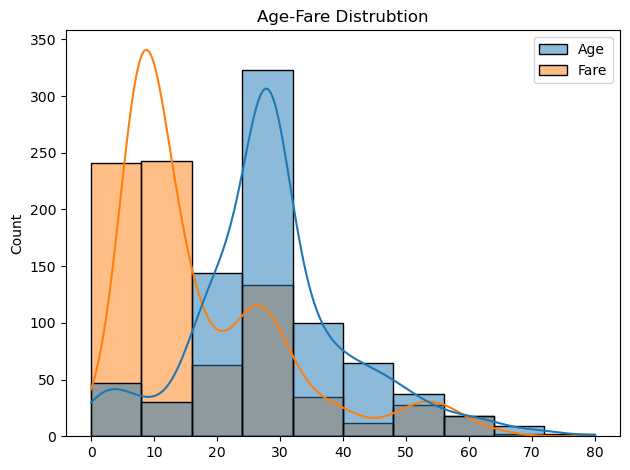

In [7]:
#Distribution plots for Age, Fare — histogram with KDE curve
sns.histplot(df[['Age', 'Fare']], bins=10, kde=True)
plt.title("Age-Fare Distrubtion")
plt.tight_layout()
plt.savefig("age_fare_distubtion.png")
plt.show()

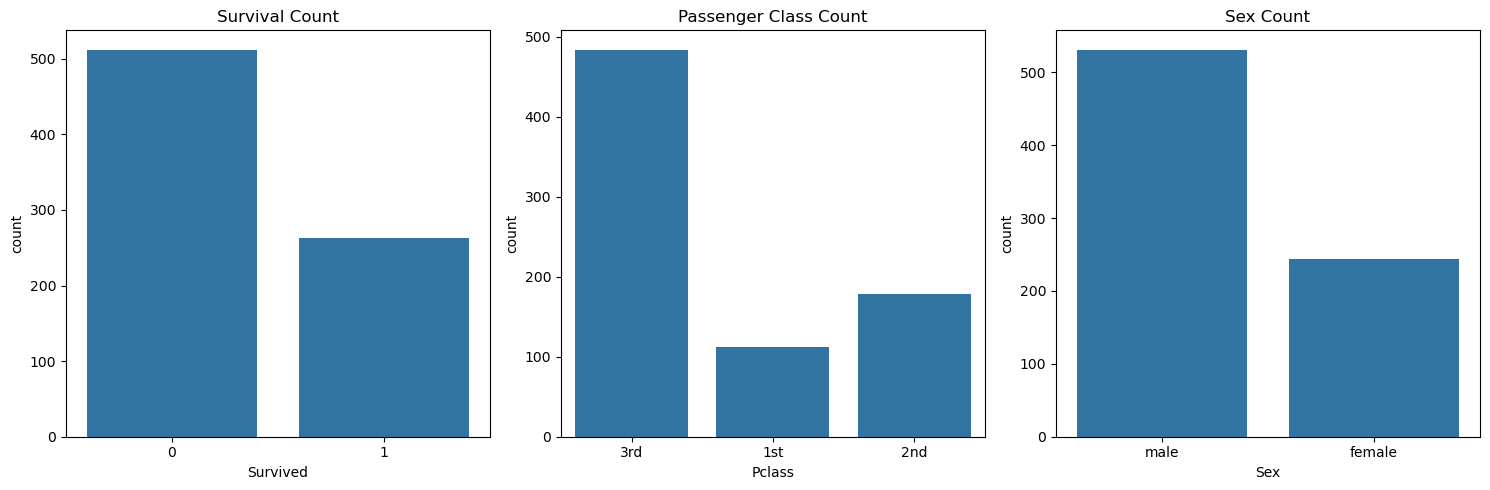

In [8]:
#Count plots for Survived, Pclass, Sex — how balanced are the classes?
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(x="Survived", data=df, ax=axes[0])
axes[0].set_title("Survival Count")
sns.countplot(x="Pclass", data=df, ax=axes[1])
axes[1].set_title("Passenger Class Count")
sns.countplot(x="Sex", data=df, ax=axes[2])
axes[2].set_title("Sex Count")
plt.tight_layout()
plt.savefig("count_plots.png")
plt.show()

Survival by Sex:
Sex
female    68.852459
male      17.890772
Name: Survived, dtype: float64
Survival by Pclass:
Pclass
1st    50.892857
2nd    48.603352
3rd    24.586777
Name: Survived, dtype: float64
Survival by Embarked:
Embarked
Cherbourg      44.827586
Queenstown     38.666667
Southampton    31.164384
Name: Survived, dtype: float64


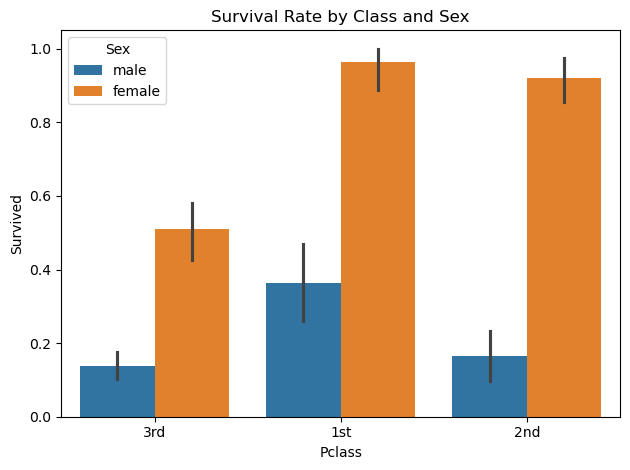

In [9]:
#Survival rate breakdown by Sex, Pclass, and Embarked using groupby
print(f"Survival by Sex:\n{df.groupby('Sex')['Survived'].mean() * 100}")
print(f"Survival by Pclass:\n{df.groupby('Pclass')['Survived'].mean() * 100}")
print(f"Survival by Embarked:\n{df.groupby('Embarked')['Survived'].mean() * 100}")

sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df)
plt.title("Survival Rate by Class and Sex")
plt.tight_layout()
plt.savefig("survival_by_class_sex.png")
plt.show()


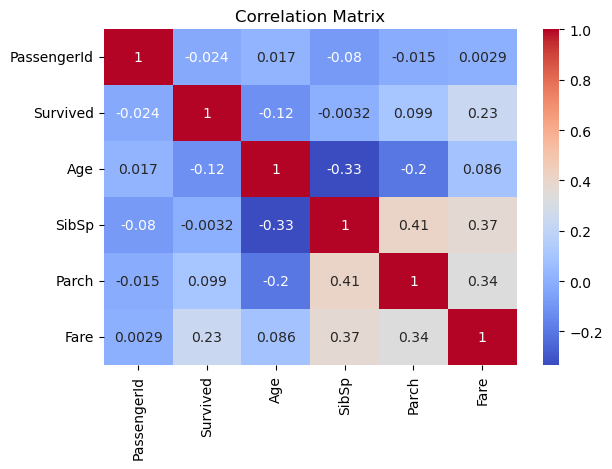

In [10]:
#Correlation heatmap of all numeric columns
correlation = df[["PassengerId", "Survived", "Age", "SibSp", "Parch", "Fare"]].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("heatmap_all_numeric_data.png")
plt.show()

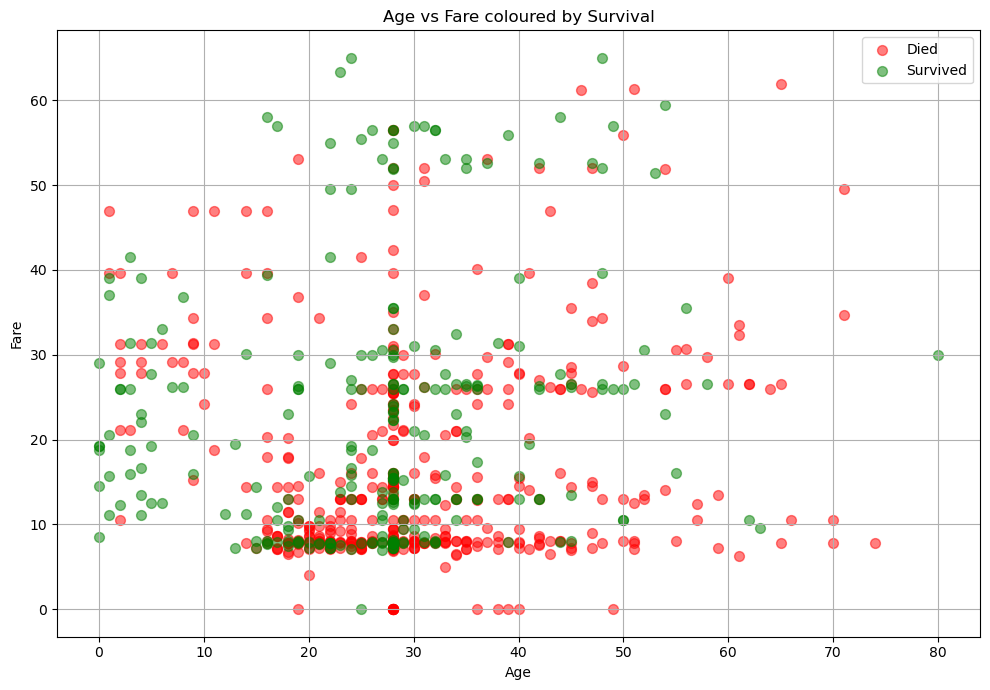

In [11]:
##Scatter plot of Age vs Fare coloured by Survived
plt.figure(figsize=(10, 7))
survived = df[df["Survived"] == 1]
died = df[df["Survived"] == 0]
plt.scatter(died["Age"], died["Fare"], alpha=0.5, s=50, label="Died", color="red")
plt.scatter(survived["Age"], survived["Fare"], alpha=0.5, s=50, label="Survived", color="green")
plt.title("Age vs Fare coloured by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("scatter_age_fare_survival.png")
plt.show()

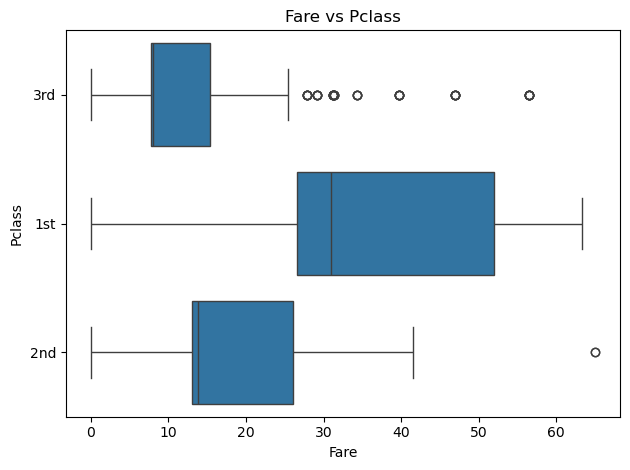

In [12]:
#Box plot of Fare by Pclass
sns.boxplot(x="Fare", y="Pclass", data=df)
plt.title("Fare vs Pclass")
plt.tight_layout()
plt.savefig("box_plot_fare_pclass.png")
plt.show()

In [13]:
#Write 5 observations as comments in your code — what does the data actually tell you?
# Observation 1: Female passengers had a significantly higher survival rate than males
# Observation 2: 1st class passengers survived at double the rate of 3rd class
# Observation 3: Age and Fare show weak correlation — older passengers didn't necessarily pay more
# Observation 4: Fare distribution is heavily right skewed — most paid little, few paid a lot
# Observation 5: Passengers embarking from Cherbourg had higher survival rates, likely because more 1st class passengers boarded there